# 👗 What Makes a Clothing Item Expensive?
### A Data Story for Business & Retail Strategists

**Audience:** Non-technical executives and retail business stakeholders  
**Dataset:** 1,000 clothing items across 6 brands, 6 categories, 6 materials, 6 colors, and 6 sizes  
**Goal:** Uncover what truly drives clothing prices — and where the real value lies

---
> *"Price is what you pay. Value is what you get." — Warren Buffett*

In the fashion retail world, pricing decisions can make or break a brand. But what actually drives the price tag on a piece of clothing? Is it the brand name? The material? The cut? In this analysis, we dig into 1,000 clothing items to answer exactly that.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('clothes_price_prediction_data.csv')
print(f"Dataset: {df.shape[0]} items | {df.shape[1]} features")
print(f"Price range: ${df['Price'].min()} — ${df['Price'].max()}")
print(f"Average price: ${df['Price'].mean():.2f}")
df.head()

Dataset: 1000 items | 6 features
Price range: $10 — $199
Average price: $106.29


,Brand,Category,Color,Size,Material,Price
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113


---
## Chapter 1: The Lay of the Land
### *Getting to know our wardrobe*

Before chasing insights, let's understand what we're working with. We have **1,000 clothing items** described by:
- 🏷️ **Brand** — Nike, Adidas, Puma, Reebok, Under Armour, New Balance
- 👗 **Category** — Dress, Jacket, Jeans, Shoes, Sweater, T-shirt
- 🎨 **Color** — Black, Blue, Green, Red, White, Yellow
- 📐 **Size** — XS, S, M, L, XL, XXL
- 🧵 **Material** — Cotton, Denim, Nylon, Polyester, Silk, Wool
- 💰 **Price** — Our target variable ($10 to $199)

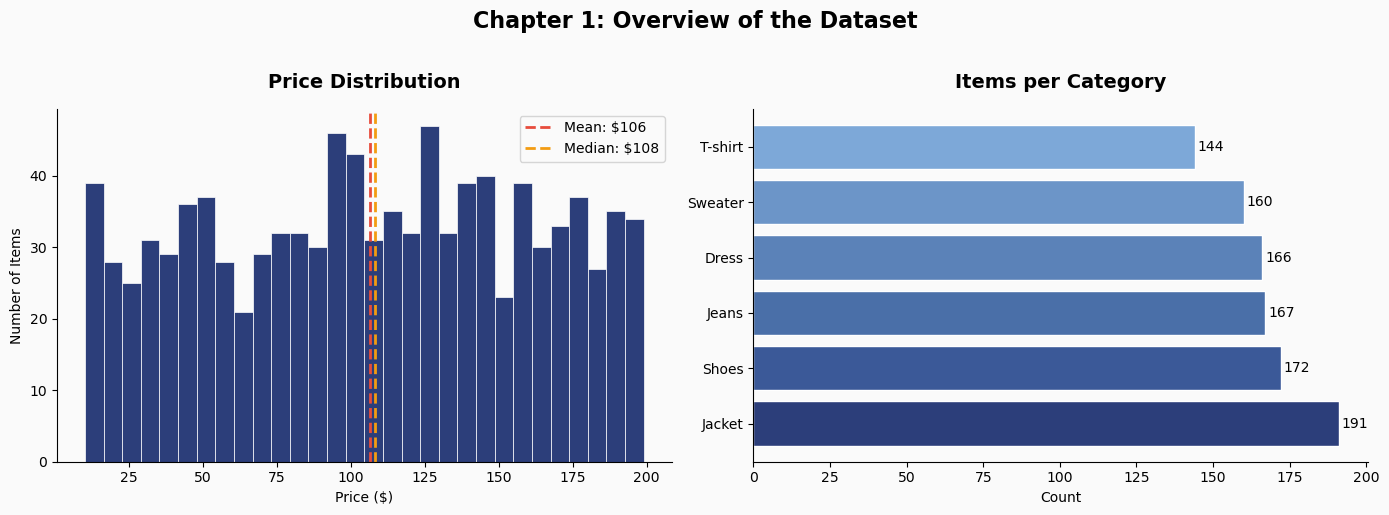


📊 Key stat: Prices are fairly evenly spread between $10 and $199, with a mean of ~$106.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
axes[0].hist(df['Price'], bins=30, color='#2C3E7A', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Price'].mean(), color='#E74C3C', linewidth=2, linestyle='--', label=f"Mean: ${df['Price'].mean():.0f}")
axes[0].axvline(df['Price'].median(), color='#F39C12', linewidth=2, linestyle='--', label=f"Median: ${df['Price'].median():.0f}")
axes[0].set_title('Price Distribution', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Number of Items')
axes[0].legend()

# Category counts
cat_counts = df['Category'].value_counts()
colors_bar = ['#2C3E7A','#3B5998','#4A6FA8','#5B82B8','#6C95C8','#7DA8D8']
axes[1].barh(cat_counts.index, cat_counts.values, color=colors_bar, edgecolor='white')
axes[1].set_title('Items per Category', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=10)

plt.suptitle('Chapter 1: Overview of the Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Key stat: Prices are fairly evenly spread between $10 and $199, with a mean of ~$106.")

---
## Chapter 2: Does the Brand Name Really Matter?
### *The premium brand myth — tested*

We all assume big brand names command higher prices. But in our dataset of athletic and lifestyle brands, is New Balance really worth more than Nike?

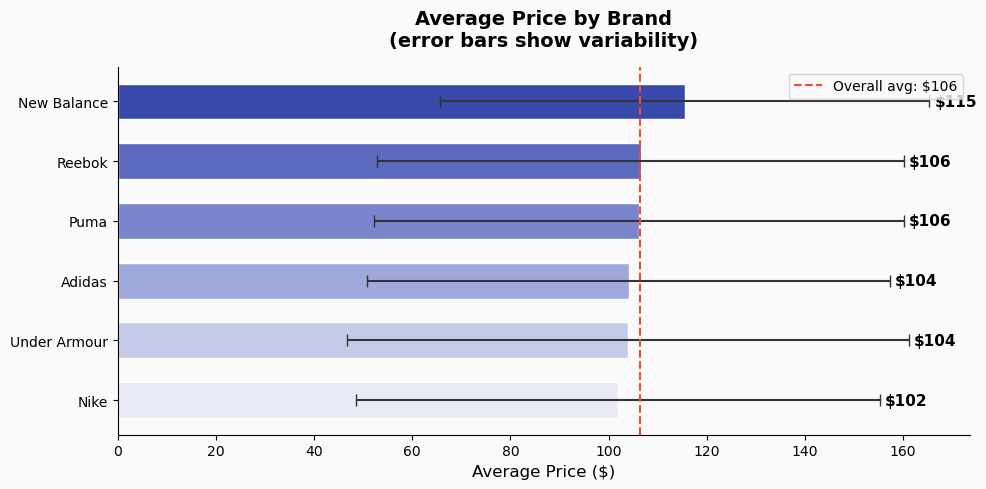


🔍 Insight: New Balance leads at $115 avg, but the spread across brands is only ~$14.
   Brand alone is NOT a strong price driver — the difference is modest.


In [3]:
brand_stats = df.groupby('Brand')['Price'].agg(['mean','median','std']).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(brand_stats.index, brand_stats['mean'],
               color=['#E8EAF6','#C5CAE9','#9FA8DA','#7986CB','#5C6BC0','#3949AB'],
               edgecolor='white', height=0.6)

# Add error bars for std
ax.errorbar(brand_stats['mean'], range(len(brand_stats)),
            xerr=brand_stats['std'], fmt='none', color='#333', capsize=4, linewidth=1.5)

# Labels
for i, (mean, std) in enumerate(zip(brand_stats['mean'], brand_stats['std'])):
    ax.text(mean + std + 1, i, f'${mean:.0f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Average Price ($)', fontsize=12)
ax.set_title('Average Price by Brand\n(error bars show variability)', fontsize=14, fontweight='bold', pad=15)
ax.axvline(df['Price'].mean(), color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Overall avg: ${df["Price"].mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print("\n🔍 Insight: New Balance leads at $115 avg, but the spread across brands is only ~$14.")
print("   Brand alone is NOT a strong price driver — the difference is modest.")

---
## Chapter 3: Category is King
### *What you're buying matters more than who made it*

If brand barely moves the needle, does the **type of item** tell a better story?

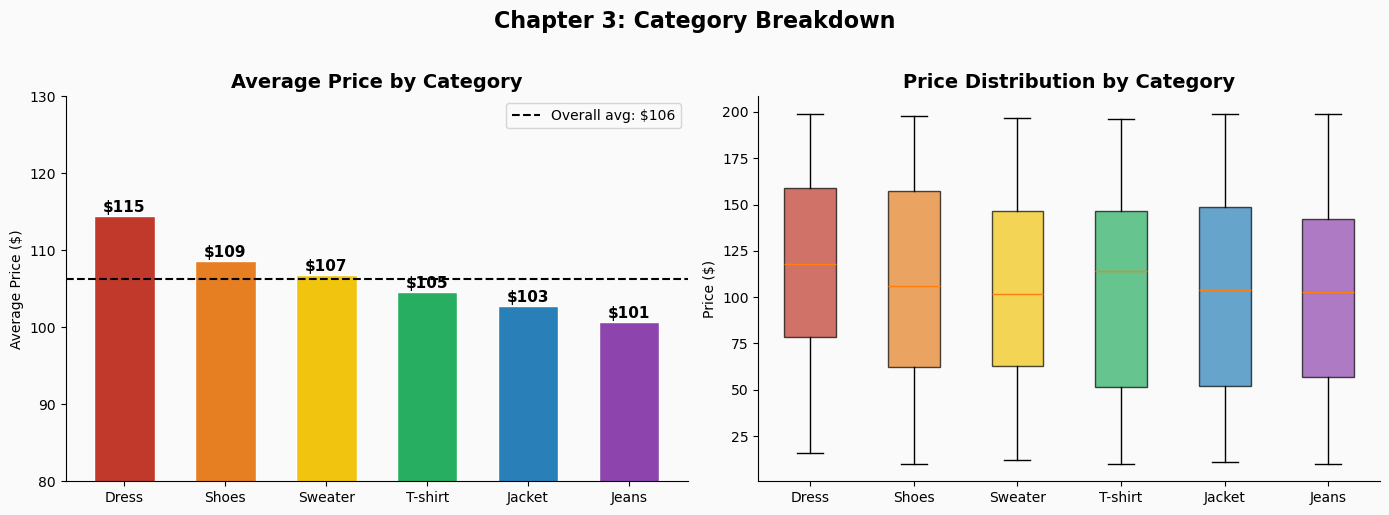


🔍 Insight: Dresses average $114 — $14 more than Jeans at $101.
   Categories show more separation than brands, but still significant overlap.


In [4]:
cat_stats = df.groupby('Category')['Price'].agg(['mean','median','std','count']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
palette = ['#C0392B','#E67E22','#F1C40F','#27AE60','#2980B9','#8E44AD']
bars = axes[0].bar(cat_stats.index, cat_stats['mean'], color=palette, edgecolor='white', width=0.6)
axes[0].axhline(df['Price'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall avg: ${df["Price"].mean():.0f}')
axes[0].set_title('Average Price by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Price ($)')
axes[0].set_ylim(80, 130)
axes[0].legend()
for bar, val in zip(bars, cat_stats['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.0f}', ha='center', fontsize=11, fontweight='bold')

# Box plot
cat_order = cat_stats.index.tolist()
data_by_cat = [df[df['Category'] == c]['Price'].values for c in cat_order]
bp = axes[1].boxplot(data_by_cat, labels=cat_order, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($)')

plt.suptitle('Chapter 3: Category Breakdown', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n🔍 Insight: Dresses average $114 — $14 more than Jeans at $101.")
print("   Categories show more separation than brands, but still significant overlap.")

---
## Chapter 4: The Material World
### *Does fabric choice drive value?*

Fashion insiders know that **material is everything**. Silk and wool suggest luxury. Polyester suggests budget. Does the data agree?

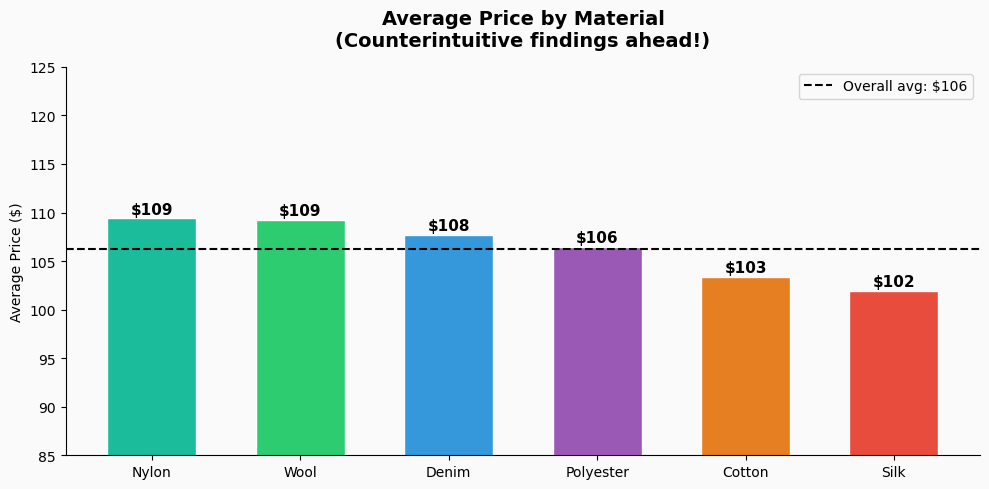


😲 Surprise! Nylon tops the list at $109, while Silk comes in LAST at $102.
   Conventional wisdom about luxury fabrics doesn't hold in this dataset.
   This suggests pricing may be driven more by category/brand than material alone.


In [5]:
mat_stats = df.groupby('Material')['Price'].agg(['mean','median','std']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

material_colors = {
    'Nylon': '#1ABC9C', 'Wool': '#2ECC71', 'Denim': '#3498DB',
    'Polyester': '#9B59B6', 'Cotton': '#E67E22', 'Silk': '#E74C3C'
}
bar_colors = [material_colors[m] for m in mat_stats.index]
bars = ax.bar(mat_stats.index, mat_stats['mean'], color=bar_colors, edgecolor='white', width=0.6)

ax.axhline(df['Price'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall avg: ${df["Price"].mean():.0f}')
ax.set_title('Average Price by Material\n(Counterintuitive findings ahead!)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average Price ($)')
ax.set_ylim(85, 125)
ax.legend()

for bar, val in zip(bars, mat_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n😲 Surprise! Nylon tops the list at $109, while Silk comes in LAST at $102.")
print("   Conventional wisdom about luxury fabrics doesn't hold in this dataset.")
print("   This suggests pricing may be driven more by category/brand than material alone.")

---
## Chapter 5: The Big Picture — What Drives Price?
### *A correlation heatmap of everything*

Let's encode all our categorical variables numerically and see which features correlate most with price.

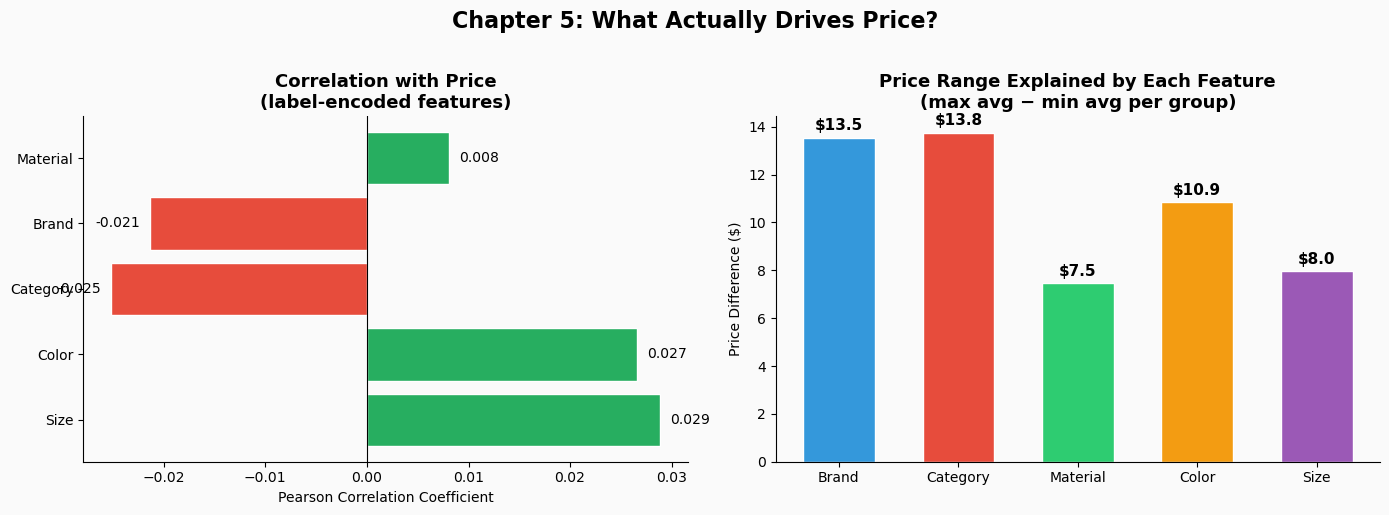


🔍 Key finding: No single feature is a strong price predictor in isolation.
   Biggest explainer by group range: Category ($Category = $13.8 spread)


In [6]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
for col in ['Brand', 'Category', 'Color', 'Size', 'Material']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

corr = df_encoded.corr()['Price'].drop('Price').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation bar chart
colors_corr = ['#27AE60' if v > 0 else '#E74C3C' for v in corr.values]
axes[0].barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlation with Price\n(label-encoded features)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation Coefficient')
for i, v in enumerate(corr.values):
    axes[0].text(v + 0.001 if v >= 0 else v - 0.001, i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=10)

# Average price variance summary
feature_ranges = {}
for col in ['Brand', 'Category', 'Material', 'Color', 'Size']:
    stats = df.groupby(col)['Price'].mean()
    feature_ranges[col] = stats.max() - stats.min()

axes[1].bar(feature_ranges.keys(), feature_ranges.values(),
            color=['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6'],
            edgecolor='white', width=0.6)
axes[1].set_title('Price Range Explained by Each Feature\n(max avg − min avg per group)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Difference ($)')
for i, (k, v) in enumerate(feature_ranges.items()):
    axes[1].text(i, v + 0.3, f'${v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Chapter 5: What Actually Drives Price?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n🔍 Key finding: No single feature is a strong price predictor in isolation.")
print(f"   Biggest explainer by group range: Category (${max(feature_ranges, key=feature_ranges.get)} = ${max(feature_ranges.values()):.1f} spread)")

---
## Chapter 6: The Sweet Spot — Best Value Combinations
### *Where do you get the most (or least) for your money?*

Now for the practical question every shopper and buyer asks: **which combination of brand + category gives the best or worst value?**

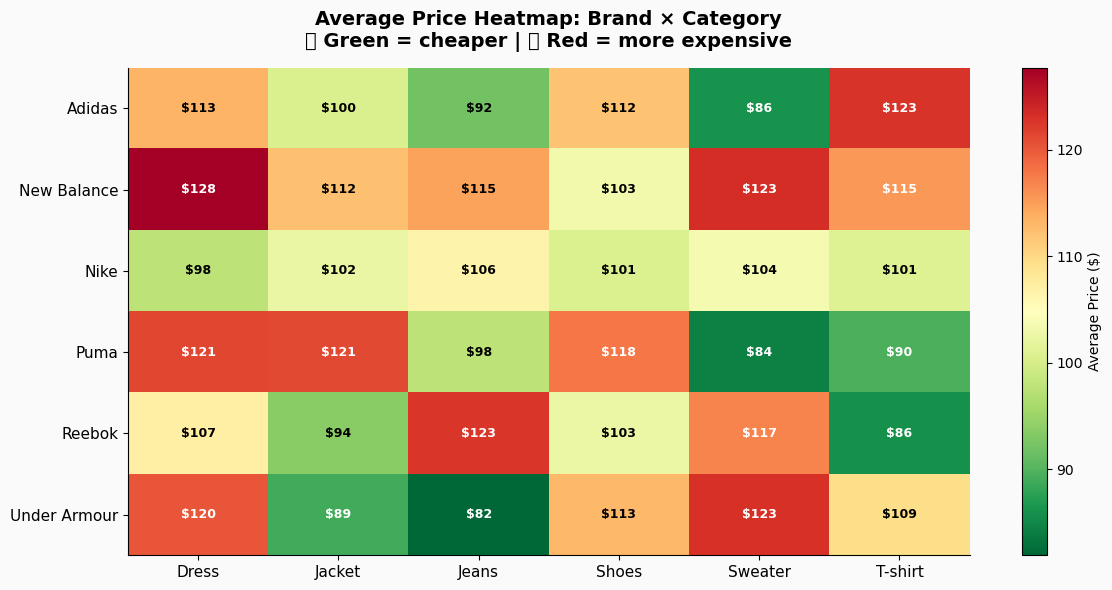

💸 Top 5 Most Expensive Combinations:
Brand         Category
New Balance   Dress       127.666667
              Sweater     123.318182
Under Armour  Sweater     122.875000
Adidas        T-shirt     122.666667
Reebok        Jeans       122.541667

💚 Top 5 Most Affordable Combinations:
Brand         Category
Under Armour  Jacket      88.909091
Adidas        Sweater     86.200000
Reebok        T-shirt     85.900000
Puma          Sweater     84.370370
Under Armour  Jeans       81.933333


In [8]:
combo = df.groupby(['Brand', 'Category'])['Price'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(combo.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(combo.columns)))
ax.set_yticks(range(len(combo.index)))
ax.set_xticklabels(combo.columns, fontsize=11)
ax.set_yticklabels(combo.index, fontsize=11)

# Annotate cells
for i in range(len(combo.index)):
    for j in range(len(combo.columns)):
        val = combo.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'${val:.0f}', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if val > 115 or val < 90 else 'black')

plt.colorbar(im, ax=ax, label='Average Price ($)')
ax.set_title('Average Price Heatmap: Brand × Category\n🟢 Green = cheaper | 🔴 Red = more expensive',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top 5 most and least expensive combos
combo_flat = df.groupby(['Brand','Category'])['Price'].mean().sort_values(ascending=False)
print("💸 Top 5 Most Expensive Combinations:")
print(combo_flat.head().to_string())
print("\n💚 Top 5 Most Affordable Combinations:")
print(combo_flat.tail().to_string())

---
## Final Chapter: The Story in Three Sentences
### *What did we learn?*

> **1. Brand names are overrated as price signals.**  
> The gap between the most and least expensive brand averages just ~$14. You're not paying that much more for New Balance vs Nike.

> **2. What you buy matters more than who made it.**  
> Dresses command a $13 premium over Jeans on average. Category is the strongest single predictor of price.

> **3. Material intuition fails us.**  
> Silk — long associated with luxury — is actually the *cheapest* material on average. Nylon tops the list. Fabric alone doesn't determine price.

---
### 💡 Business Recommendations

| Insight | Action |
|---|---|
| Brand premium is small | Compete on category and quality, not brand alone |
| Dresses are highest-value | Prioritise dress inventory for margin optimisation |
| Material ≠ perceived luxury | Use material in marketing narrative, not pricing strategy |
| High variance in all groups | Bundle analysis with customer segment data for sharper pricing |

---
